In [1]:
import subprocess, sys

# Ensure opencv-contrib-python (required for SIFT in older OpenCV builds)
try:
    import cv2
    assert hasattr(cv2, "SIFT_create"), "SIFT not available"
except (ImportError, AssertionError):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "opencv-contrib-python"])
    import cv2

print(f"OpenCV {cv2.__version__}  — SIFT available: {hasattr(cv2, 'SIFT_create')}")


OpenCV 4.13.0  — SIFT available: True


In [2]:
%matplotlib inline

import os
import urllib.request

import cv2
import numpy as np
import matplotlib.pyplot as plt

print(f"OpenCV  : {cv2.__version__}")
print(f"NumPy   : {np.__version__}")


def fetch(url: str, filename: str) -> np.ndarray:
    if not os.path.exists(filename):
        print(f"Downloading {filename} …")
        urllib.request.urlretrieve(url, filename)
    img = cv2.imread(filename)
    if img is None:
        raise RuntimeError(f"Could not decode: {filename}")
    return img


def show(images, titles, figsize=(16, 5)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img
        ax.imshow(disp, cmap="gray" if img.ndim == 2 else None)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


OpenCV  : 4.13.0
NumPy   : 2.0.2


Image 1 shape : (223, 324, 3)
Image 2 shape : (384, 512, 3)


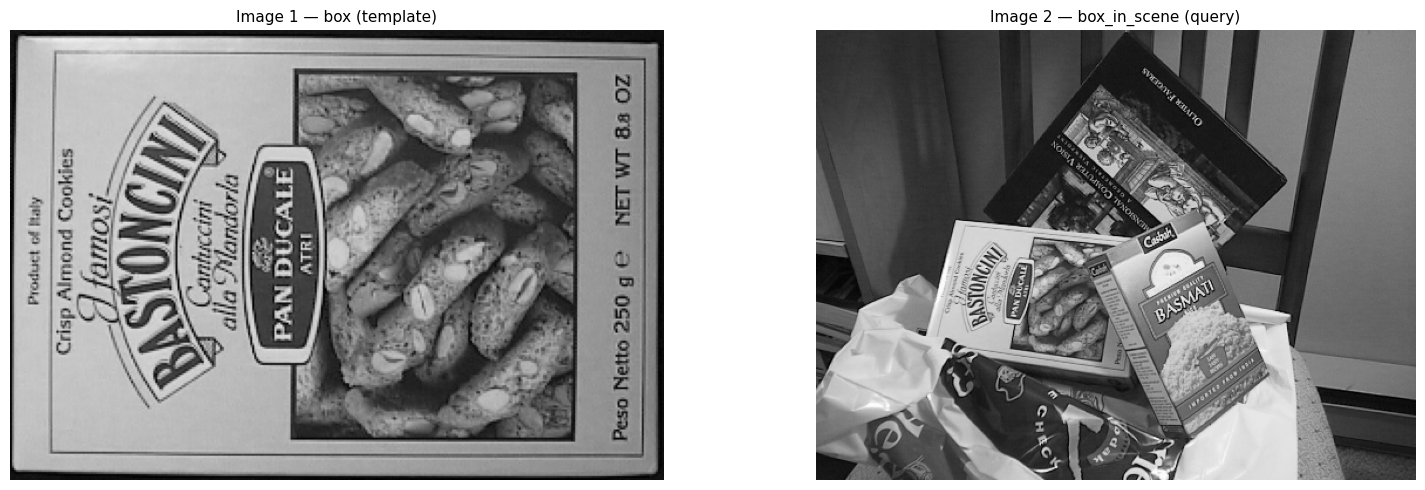

In [3]:
BASE = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/"

img1 = fetch(BASE + "box.png",          "sift_img1.png")
img2 = fetch(BASE + "box_in_scene.png", "sift_img2.png")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

print(f"Image 1 shape : {img1.shape}")
print(f"Image 2 shape : {img2.shape}")

show([img1, img2], ["Image 1 — box (template)", "Image 2 — box_in_scene (query)"])


Image 1 keypoints :   604
Image 2 keypoints :   969
Descriptor shape  : (604, 128)  (n × 128)


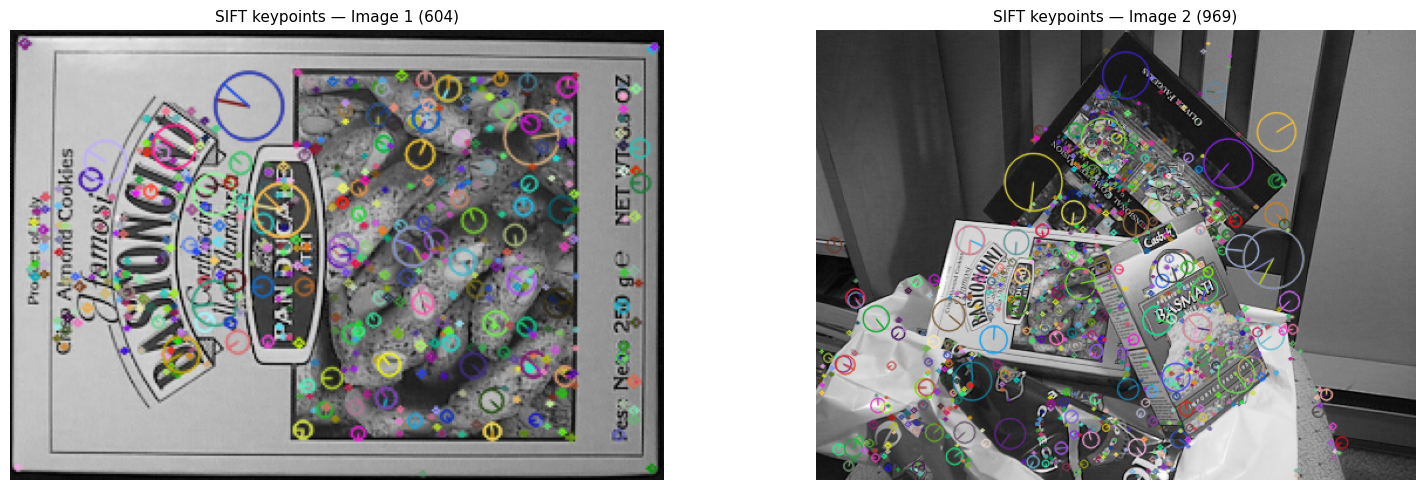

In [4]:
sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

print(f"Image 1 keypoints : {len(kp1):5d}")
print(f"Image 2 keypoints : {len(kp2):5d}")
print(f"Descriptor shape  : {des1.shape}  (n × 128)")

kp_img1 = cv2.drawKeypoints(gray1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
kp_img2 = cv2.drawKeypoints(gray2, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

show(
    [kp_img1, kp_img2],
    [f"SIFT keypoints — Image 1 ({len(kp1)})", f"SIFT keypoints — Image 2 ({len(kp2)})"],
)


In [5]:
RATIO_THRESH = 0.75

index_params  = dict(algorithm=1, trees=5)   # FLANN_INDEX_KDTREE
search_params = dict(checks=50)

flann = cv2.FlannBasedMatcher(index_params, search_params)
raw   = flann.knnMatch(des1, des2, k=2)
good  = [m for m, n in raw if m.distance < RATIO_THRESH * n.distance]

print(f"Raw candidate pairs   : {len(raw)}")
print(f"After Lowe ratio test : {len(good)}  (threshold = {RATIO_THRESH})")


Raw candidate pairs   : 604
After Lowe ratio test : 81  (threshold = 0.75)


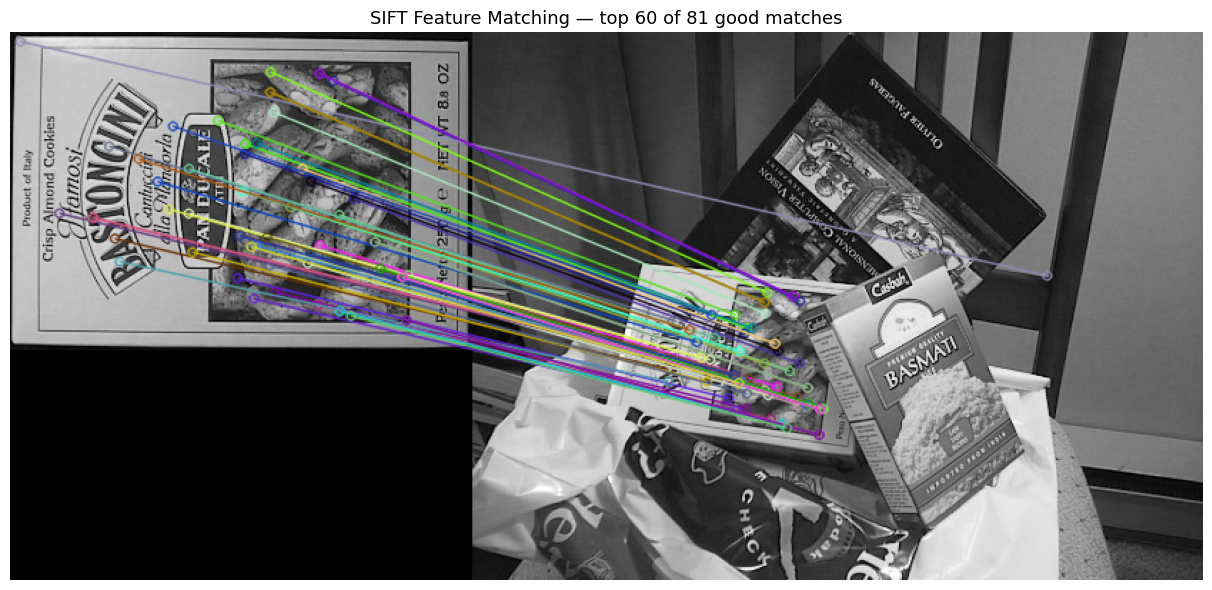

In [6]:
DISPLAY_N = 60
top_matches = sorted(good, key=lambda m: m.distance)[:DISPLAY_N]

match_img = cv2.drawMatches(
    img1, kp1, img2, kp2, top_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

plt.figure(figsize=(18, 6))
plt.imshow(cv2.cvtColor(match_img, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Feature Matching — top {DISPLAY_N} of {len(good)} good matches", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()


Total good matches : 81
RANSAC inliers     : 74
Outliers rejected  : 7

Homography matrix (3×3):
[[ 4.425000e-01 -1.626000e-01  1.188017e+02]
 [ 1.000000e-03  4.059000e-01  1.609007e+02]
 [-2.000000e-04 -3.000000e-04  1.000000e+00]]


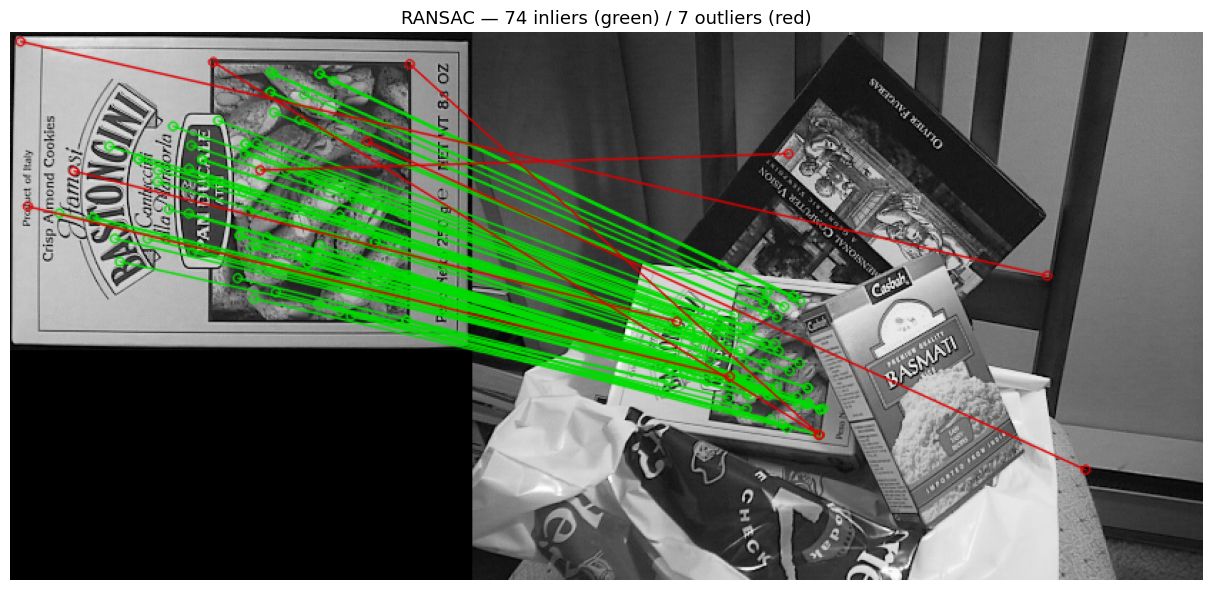

In [7]:
MIN_MATCH = 10

if len(good) < MIN_MATCH:
    print(f"Only {len(good)} matches — need at least {MIN_MATCH}. Lower RATIO_THRESH.")
else:
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransacReprojThreshold=5.0)
    mask_flat = mask.ravel().tolist()

    inlier_count = int(mask.sum())
    print(f"Total good matches : {len(good)}")
    print(f"RANSAC inliers     : {inlier_count}")
    print(f"Outliers rejected  : {len(good) - inlier_count}")
    print("\nHomography matrix (3×3):")
    print(np.round(H, 4))

    inliers  = [m for m, keep in zip(good, mask_flat) if keep]
    outliers = [m for m, keep in zip(good, mask_flat) if not keep]

    vis = cv2.drawMatches(
        img1, kp1, img2, kp2, inliers, None,
        matchColor=(0, 220, 0),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
    )
    vis = cv2.drawMatches(
        img1, kp1, img2, kp2, outliers, vis,
        matchColor=(0, 0, 220),
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS | cv2.DrawMatchesFlags_DRAW_OVER_OUTIMG,
    )

    plt.figure(figsize=(18, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(
        f"RANSAC — {inlier_count} inliers (green) / {len(good) - inlier_count} outliers (red)",
        fontsize=13,
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()


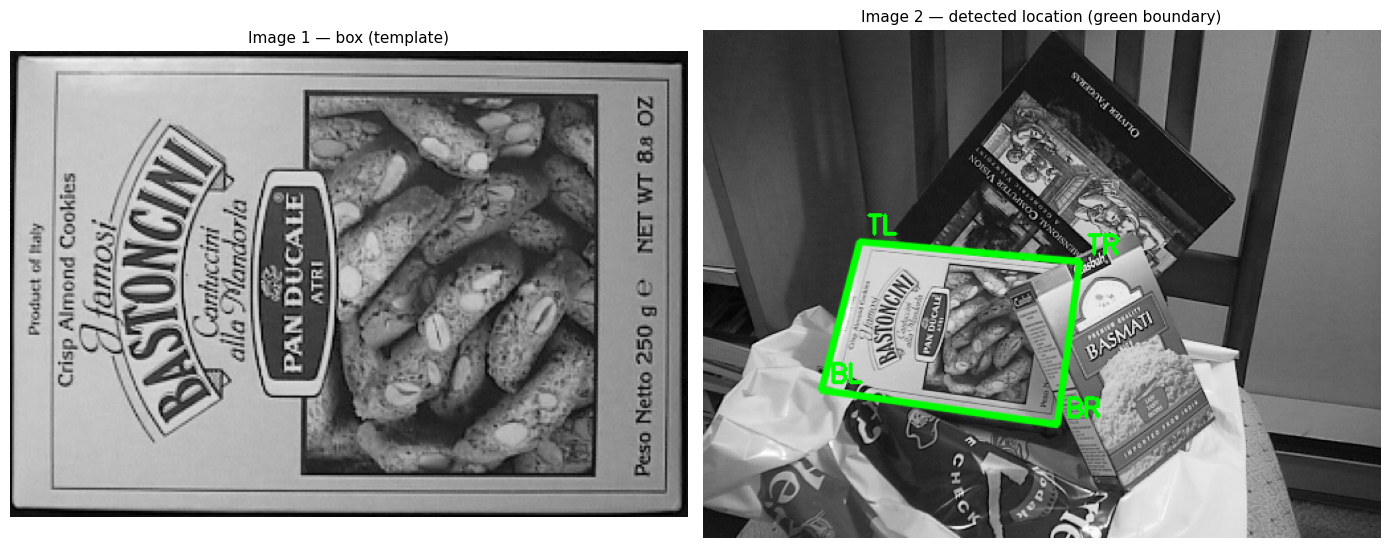

Projected corners: [[118, 160], [284, 175], [267, 298], [89, 272]]


In [8]:
h1, w1 = img1.shape[:2]
corners = np.float32([[0, 0], [w1, 0], [w1, h1], [0, h1]]).reshape(-1, 1, 2)
corners_warped = cv2.perspectiveTransform(corners, H)

scene = img2.copy()
cv2.polylines(
    scene, [np.int32(corners_warped)],
    isClosed=True, color=(0, 255, 0), thickness=3, lineType=cv2.LINE_AA,
)
for pt, lbl in zip(corners_warped.reshape(-1, 2), ["TL", "TR", "BR", "BL"]):
    cv2.putText(
        scene, lbl, (int(pt[0]) + 6, int(pt[1]) - 6),
        cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2,
    )

show(
    [img1, scene],
    ["Image 1 — box (template)", "Image 2 — detected location (green boundary)"],
    figsize=(14, 6),
)
print(f"Projected corners: {np.int32(corners_warped).reshape(-1, 2).tolist()}")
